<a href="https://colab.research.google.com/github/mayura-andrew/ml-experiments/blob/main/supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 9.7 MB/s eta 0:00:00


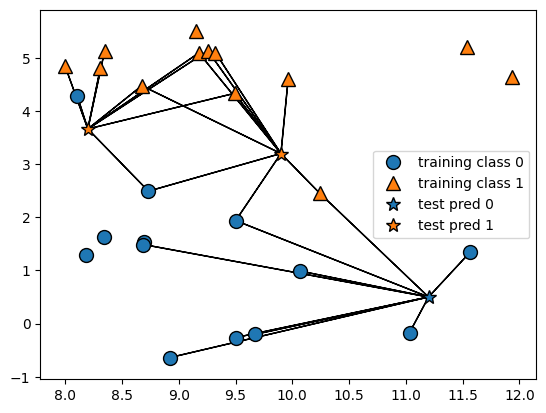

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import mglearn # Import the mglearn library for plotting utilities

# knn_model = KNeighborsClassifier(n_neighbors=3)

mglearn.plots.plot_knn_classification(n_neighbors=9)

In [ ]:
from sklearn.model_selection import train_test_split
X, y = mglearn.datasets.make_forge()
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)

print("Test set predictions: {}".format(clf.predict(X_test)))
print("Test set accuracy: {:.2f}".format(clf.score(X_test, y_test)))


Test set predictions: [1 1 1 1 0 1 0]
Test set accuracy: 0.86


# Decision Boundary

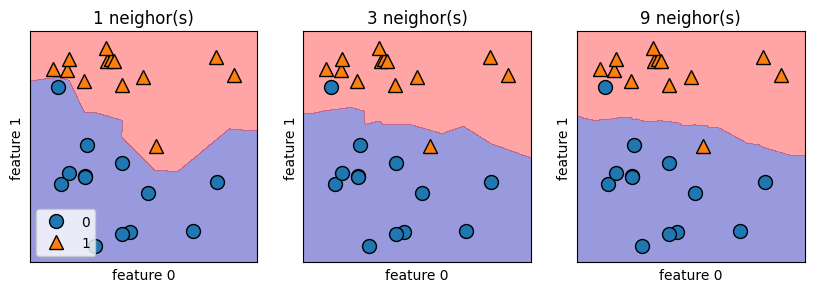

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for n_neighbors, ax in zip([1, 3, 9], axes):
  clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
  mglearn.plots.plot_2d_separator(clf, X, fill=True, eps=0.5, ax=ax, alpha=.4)
  mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
  ax.set_title("{} neighor(s)".format(n_neighbors))
  ax.set_xlabel("feature 0")
  ax.set_ylabel("feature 1")
axes[0].legend(loc=3)

# Model Complexity vs Generalization

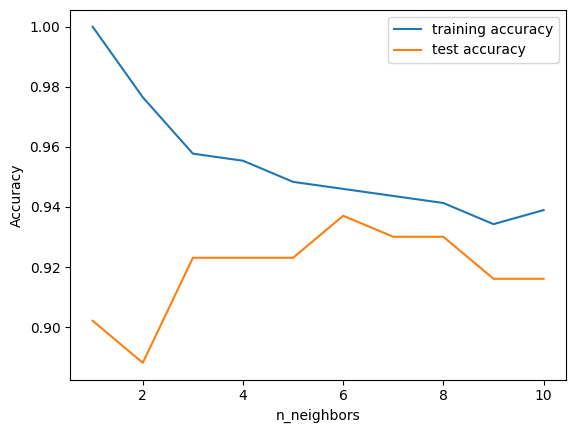

In [ ]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=66)

training_accuracy = []
test_accuracy = []

neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
  clf = KNeighborsClassifier(n_neighbors=n_neighbors)
  clf.fit(X_train, y_train)
  # record training set accuracy
  training_accuracy.append(clf.score(X_train, y_train))
  # record generalization accuracy
  test_accuracy.append(clf.score(X_test, y_test))

plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()



# k-neighbors regression


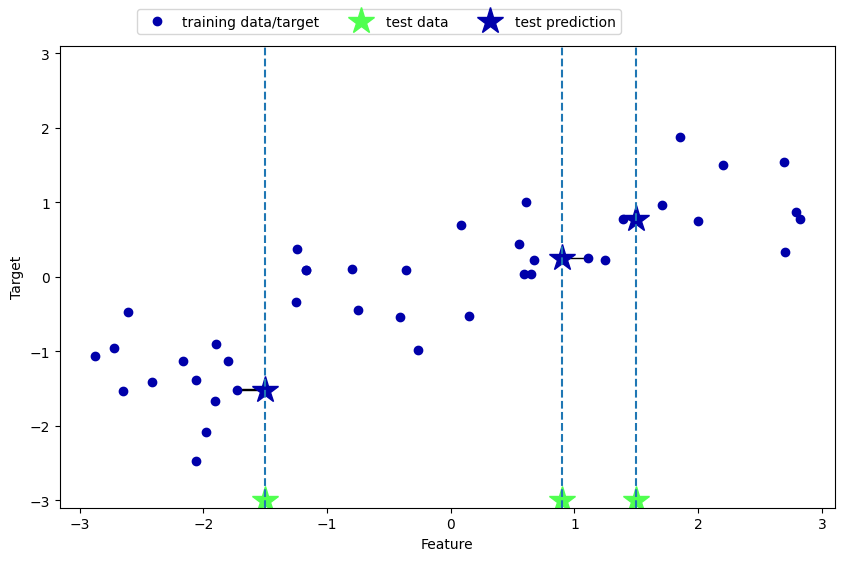

In [ ]:
mglearn.plots.plot_knn_regression(n_neighbors=1)

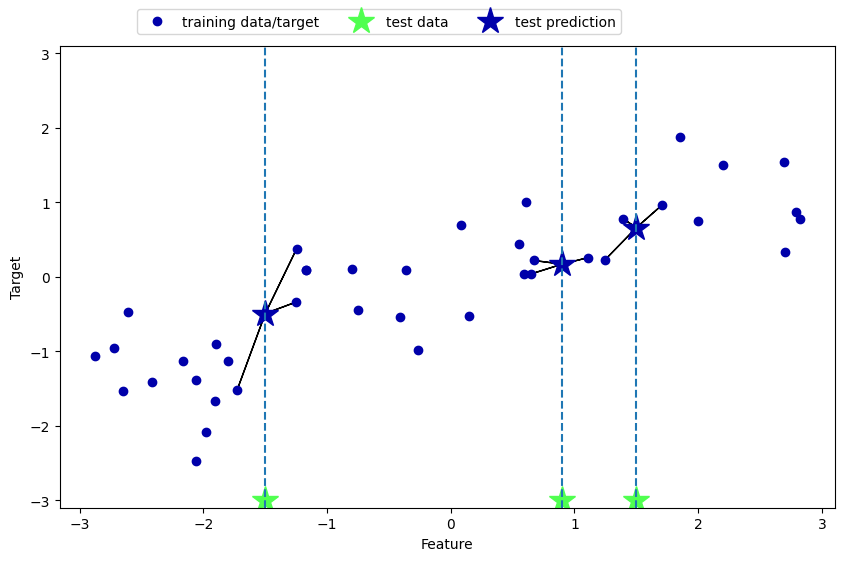

In [ ]:
mglearn.plots.plot_knn_regression(n_neighbors=3)

# the k-nearest neighbirs algorithm for regression is implemented in the KNeighbors Regressor class in scikit-learn.

In [16]:
from sklearn.neighbors import KNeighborsRegressor

X, y = mglearn.datasets.make_wave(n_samples=40)

# split the wave dataset into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# instantiate the model and set the number of neighbors to consider to 3

reg = KNeighborsRegressor(n_neighbors=3)
# fit the model using the training data
reg.fit(X_train, y_train)

print("Test set predictions:\n{}".format(reg.predict(X_test)))

Test set predictions:
[ 0.18836016  0.18836016 -2.07693788 -1.75751624 -1.89415682  1.44592491
 -0.85177421 -0.35898987 -0.65851598 -0.8301424 ]


The number 42 is frequently used as a random_state in machine learning experiments, particularly in tutorials and examples. It's a convention rather than a strict requirement, and it stems from Douglas Adams' science fiction novel "The Hitchhiker's Guide to the Galaxy," where 42 is revealed to be the "Answer to the Ultimate Question of Life, the Universe, and Everything."

In a more practical sense, using a fixed number like 42 for random_state ensures reproducibility. When you set random_state to a specific integer, the random number generator will produce the same sequence of random numbers every time the code is run. This is crucial for:

    Reproducibility: Others (or even yourself in the future) can get the exact same results when running your code.
    Debugging: It helps in identifying issues in your model or data processing, as the randomness is controlled.
    Fair comparison: When comparing different models or hyperparameter settings, using the same random_state for data splitting or initialization ensures that the differences in performance are due to the changes you made, not just different random splits.

While 42 is common, any integer can be used. The important thing is to use a fixed integer for reproducibility.


The implementation of random_state (or a similar seed mechanism in other libraries/languages) is fundamental to ensuring that algorithms relying on randomness can produce consistent results. Here's why it's designed this way:

    Pseudorandom Number Generators (PRNGs): Computers don't generate truly random numbers. Instead, they use algorithms called pseudorandom number generators (PRNGs). These algorithms produce a sequence of numbers that appear random but are actually deterministic. This means that if you start the PRNG with the same initial value (the "seed"), it will produce the exact same sequence of "random" numbers.

    Control over Initial State: The random_state parameter allows you to explicitly set this initial seed for the PRNG. If you don't set it, many libraries will use a default seed, often based on the current system time. While this makes each run unique, it makes reproducibility impossible.

    Debugging and Validation: In machine learning, many algorithms involve random processes (e.g., initializing weights in neural networks, shuffling data for training/testing, random subsampling). If a bug occurs, or if you want to validate a model's performance, being able to re-run the exact same experiment with the same random splits and initializations is crucial. Without a fixed random_state, it would be very difficult to isolate the cause of an issue or to confirm that a change improved the model, as the underlying random factors would also be different.

    Scientific Reproducibility: In scientific research, it's paramount that results can be independently verified. Providing a random_state in published code ensures that other researchers can replicate the experimental setup and obtain the same results, fostering trust and allowing for further advancements based on solid foundations.

    Fair Comparisons: When comparing different models or hyperparameter settings, you want to ensure that any observed differences in performance are due to the models or parameters themselves, not just different random data splits or initial conditions. A fixed random_state eliminates this source of variability.

In essence, while the goal is to introduce randomness, the ability to control that randomness through random_state is what makes machine learning experiments robust, debuggable, and scientifically sound.


In [17]:
print("Test set R^2: {: .2f}".format(reg.score(X_test, y_test)))

Test set R^2:  0.24


The R^2 score, also known as the coefficient of determination, is a measure of how well the regression predictions approximate the real data points. An R^2 of 1 indicates that the regression predictions perfectly fit the data. An R^2 of 0.24 means that approximately 24% of the variance in the dependent variable (y) can be explained by the independent variable (X) using this model. The remaining 76% of the variance is unexplained. This score suggests that the model provides a relatively weak fit to the data for the given `random_state=42` split.

# Analyzing KNeighborsRegressor

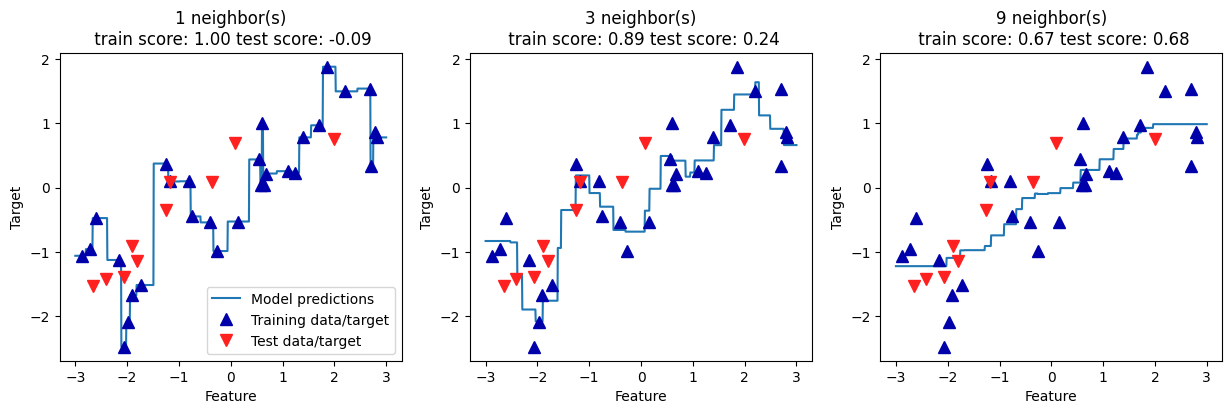

In [19]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#create 1,000 data points, evenly spaced between -3 and 3

line = np.linspace(-3, 3, 1000).reshape(-1, 1)
for n_neighbors, ax in zip([1, 3, 9], axes):
  # make predictions using 1, 3, or 9 neighbors
  reg = KNeighborsRegressor(n_neighbors=n_neighbors)
  reg.fit(X_train, y_train)
  ax.plot(line, reg.predict(line))
  ax.plot(X_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
  ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)


  ax.set_title(
      "{} neighbor(s)\n train score: {:.2f} test score: {:.2f}".format(
          n_neighbors, reg.score(X_train, y_train),
          reg.score(X_test, y_test))),
  ax.set_xlabel("Feature")
  ax.set_ylabel("Target")
axes[0].legend(["Model predictions", "Training data/target",
                "Test data/target"], loc="best")

In principle, there are two important parameters to the KNeighbors classifier: ***the number of neighbors*** and ***how you measure distance between data points***


when your training set is very large (either in number of features or in number of samples) prediction can be slow.

When dealing with sparse datasets (where most feature values are zero), the `KNeighborsClassifier` and `KNeighborsRegressor` can behave differently than with dense datasets. Distance calculations in high-dimensional sparse spaces can sometimes be counter-intuitive.

For example, if using Euclidean distance, two samples might appear very close if they share common non-zero features, even if they are otherwise very different across many zero-valued features. Some distance metrics might be more appropriate for sparse data (e.g., Jaccard distance or cosine similarity, though scikit-learn's KNeighbors typically uses Minkowski distance, which includes Euclidean and Manhattan as special cases).

Additionally, predicting on sparse data can be slow, especially if the dataset is large. This is because all training samples need to be stored, and a distance calculation needs to be performed for each test sample against every training sample. If efficiency is a concern with sparse data, other models might be more suitable, or dimensionality reduction techniques could be applied.